# 01 - Exploración del Dataset
**Proyecto:** Detección Asistida de Leucemia Linfoblástica Aguda (LLA)  
**Dataset:** Acute Lymphoblastic Leukemia (ALL) - Kaggle  
**Objetivo:** Cargar, visualizar y entender la estructura del dataset antes de preprocesar.

## 1. Importación de librerías

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
from pathlib import Path
from collections import Counter

In [2]:
import matplotlib.patches as mpatches
import cv2
from pathlib import Path
from collections import Counter

In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm

# Si no tenés tqdm instalado:
# py -m pip install tqdm

## 2. Definición de rutas

In [4]:
# Ruta base del dataset (ajustar si es necesario)
BASE_PATH = Path('../data/raw/Segmented')

CLASSES = ['Benign', 'Early', 'Pre', 'Pro']

# Verificar que las carpetas existen
for cls in CLASSES:
    path = BASE_PATH / cls
    exists = path.exists()
    print(f'{cls}: {path} -> {"OK" if exists else "NO ENCONTRADA"}')

Benign: ..\data\raw\Segmented\Benign -> NO ENCONTRADA
Early: ..\data\raw\Segmented\Early -> NO ENCONTRADA
Pre: ..\data\raw\Segmented\Pre -> NO ENCONTRADA
Pro: ..\data\raw\Segmented\Pro -> NO ENCONTRADA


## 3. Conteo de imágenes por clase

In [5]:
conteo = {}
for cls in CLASSES:
    imagenes = list((BASE_PATH / cls).glob('*.jpg')) + list((BASE_PATH / cls).glob('*.png'))
    conteo[cls] = len(imagenes)
    print(f'{cls}: {len(imagenes)} imágenes')

total = sum(conteo.values())
print(f'\nTotal: {total} imágenes')

# Clasificación binaria: Benign vs ALL
n_benign = conteo['Benign']
n_all = conteo['Early'] + conteo['Pre'] + conteo['Pro']
print(f'\nClasificación binaria:')
print(f'  Benign (sanas): {n_benign} ({100*n_benign/total:.1f}%)')
print(f'  ALL (leucémicas): {n_all} ({100*n_all/total:.1f}%)')

Benign: 0 imágenes
Early: 0 imágenes
Pre: 0 imágenes
Pro: 0 imágenes

Total: 0 imágenes

Clasificación binaria:


ZeroDivisionError: division by zero

## 4. Visualización de distribución de clases

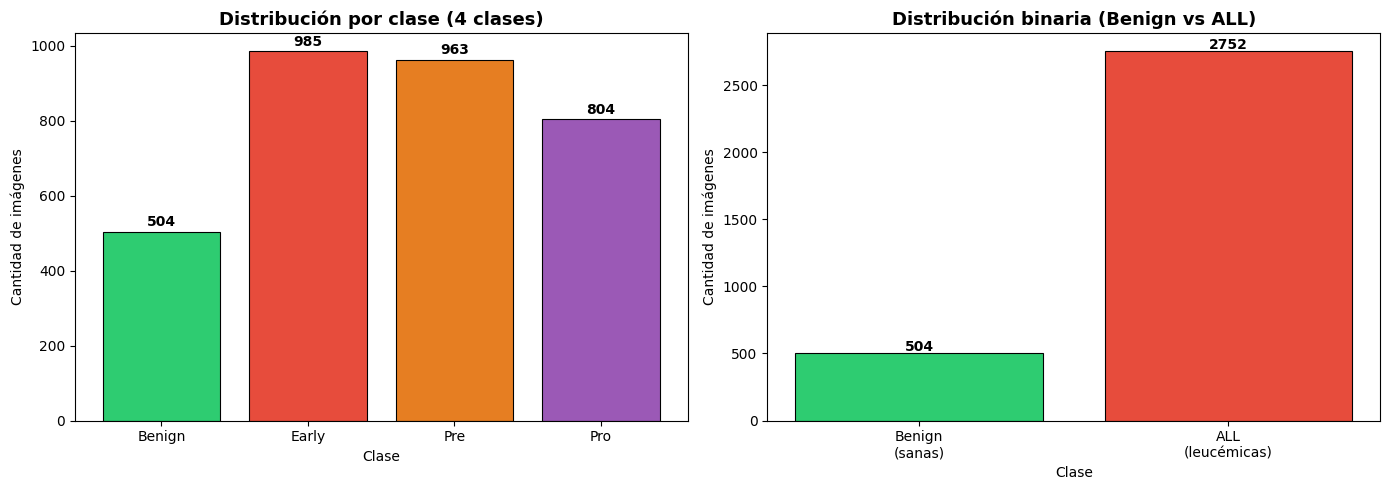

Gráfico guardado en results/distribucion_clases.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: 4 clases originales ---
colores = ['#2ecc71', '#e74c3c', '#e67e22', '#9b59b6']
axes[0].bar(conteo.keys(), conteo.values(), color=colores, edgecolor='black', linewidth=0.8)
axes[0].set_title('Distribución por clase (4 clases)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Cantidad de imágenes')
for i, (cls, val) in enumerate(conteo.items()):
    axes[0].text(i, val + 15, str(val), ha='center', fontweight='bold')

# --- Gráfico 2: clasificación binaria ---
binario = {'Benign\n(sanas)': n_benign, 'ALL\n(leucémicas)': n_all}
colores_bin = ['#2ecc71', '#e74c3c']
axes[1].bar(binario.keys(), binario.values(), color=colores_bin, edgecolor='black', linewidth=0.8)
axes[1].set_title('Distribución binaria (Benign vs ALL)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('Cantidad de imágenes')
for i, (cls, val) in enumerate(binario.items()):
    axes[1].text(i, val + 15, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado en results/distribucion_clases.png')

## 5. Visualización de imágenes de muestra

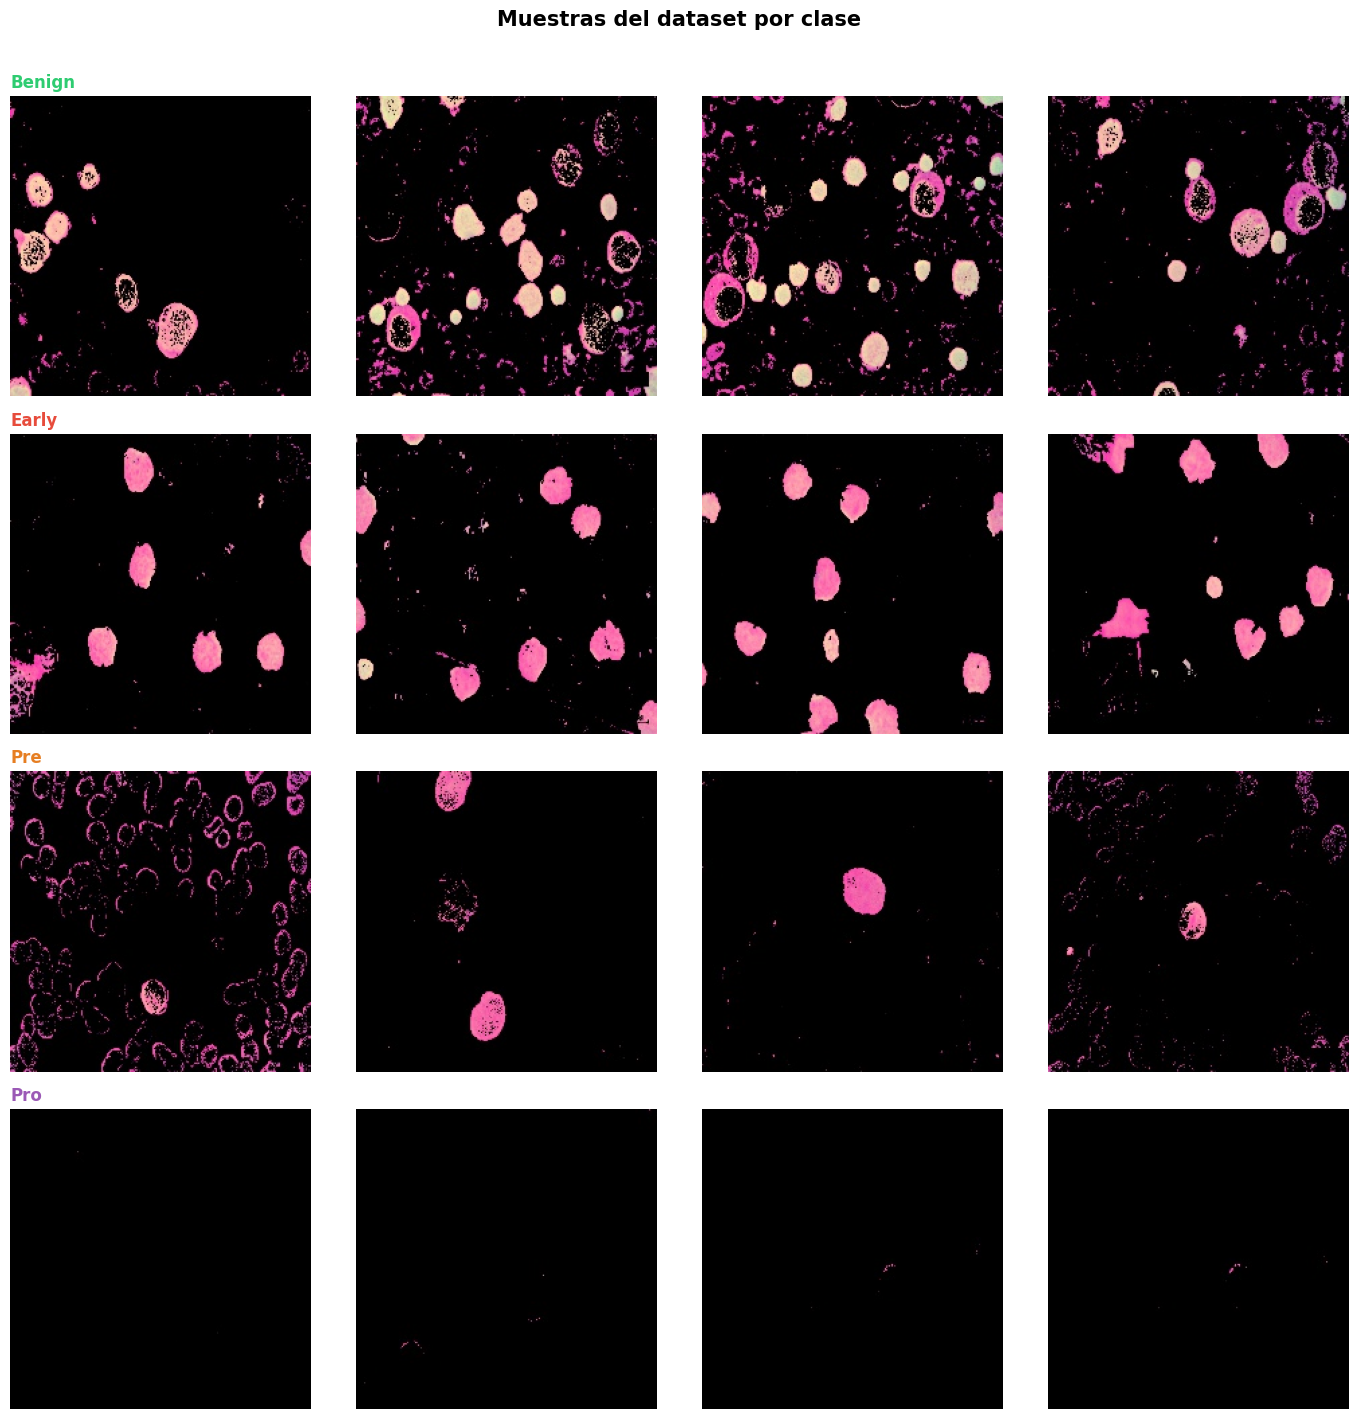

Gráfico guardado en results/muestras_por_clase.png


In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
fig.suptitle('Muestras del dataset por clase', fontsize=15, fontweight='bold', y=1.01)

colores_titulo = {'Benign': '#2ecc71', 'Early': '#e74c3c', 'Pre': '#e67e22', 'Pro': '#9b59b6'}

for row, cls in enumerate(CLASSES):
    imagenes = list((BASE_PATH / cls).glob('*.jpg')) + list((BASE_PATH / cls).glob('*.png'))
    muestras = imagenes[:4]  # primeras 4 imágenes de cada clase
    for col, img_path in enumerate(muestras):
        img = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[row, col].imshow(img_rgb)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(cls, fontsize=12, fontweight='bold',
                                     color=colores_titulo[cls], loc='left')

plt.tight_layout()
plt.savefig('../results/muestras_por_clase.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado en results/muestras_por_clase.png')

## 6. Análisis de dimensiones y canales

In [ ]:
print('Analizando dimensiones de imágenes (muestra de 20 por clase)...\n')

dimensiones = {}
for cls in CLASSES:
    imagenes = list((BASE_PATH / cls).glob('*.jpg')) + list((BASE_PATH / cls).glob('*.png'))
    shapes = []
    for img_path in imagenes[:20]:
        img = cv2.imread(str(img_path))
        shapes.append(img.shape)  # (alto, ancho, canales)
    dimensiones[cls] = shapes
    shapes_unicas = Counter(shapes)
    print(f'{cls}:')
    for shape, count in shapes_unicas.most_common(3):
        print(f'  {shape} -> {count} imágenes')

Analizando dimensiones de imágenes (muestra de 20 por clase)...

Benign:
  (224, 224, 3) -> 20 imágenes
Early:
  (224, 224, 3) -> 20 imágenes
Pre:
  (224, 224, 3) -> 20 imágenes
Pro:
  (224, 224, 3) -> 20 imágenes


## 7. Análisis de canales de color (RGB vs HSV)

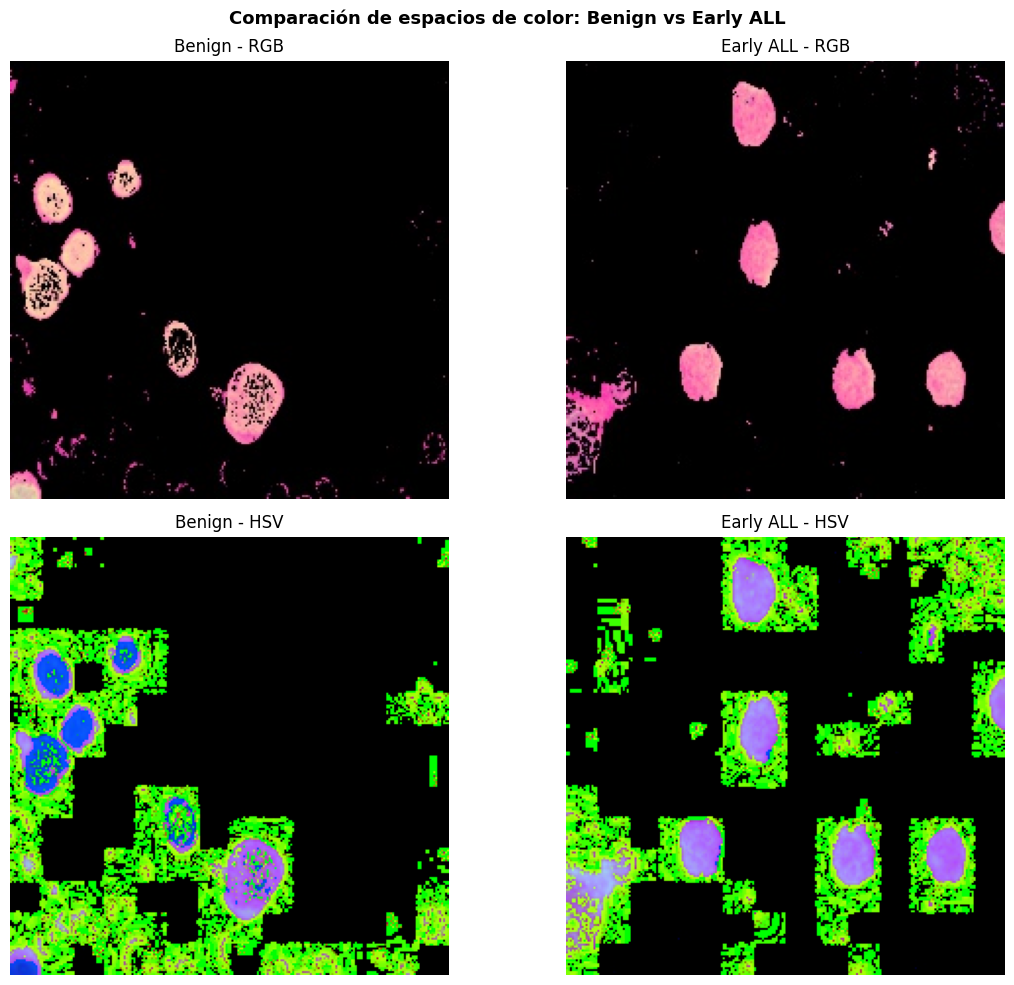

Gráfico guardado en results/comparacion_espacios_color.png


In [ ]:
# Comparar una imagen Benign vs una ALL en RGB y HSV
img_benign_path = list((BASE_PATH / 'Benign').glob('*.jpg'))[0]
img_all_path    = list((BASE_PATH / 'Early').glob('*.jpg'))[0]

img_b = cv2.cvtColor(cv2.imread(str(img_benign_path)), cv2.COLOR_BGR2RGB)
img_a = cv2.cvtColor(cv2.imread(str(img_all_path)),    cv2.COLOR_BGR2RGB)

img_b_hsv = cv2.cvtColor(cv2.imread(str(img_benign_path)), cv2.COLOR_BGR2HSV)
img_a_hsv = cv2.cvtColor(cv2.imread(str(img_all_path)),    cv2.COLOR_BGR2HSV)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Comparación de espacios de color: Benign vs Early ALL', fontsize=13, fontweight='bold')

axes[0, 0].imshow(img_b);       axes[0, 0].set_title('Benign - RGB');       axes[0, 0].axis('off')
axes[0, 1].imshow(img_a);       axes[0, 1].set_title('Early ALL - RGB');     axes[0, 1].axis('off')
axes[1, 0].imshow(img_b_hsv);   axes[1, 0].set_title('Benign - HSV');        axes[1, 0].axis('off')
axes[1, 1].imshow(img_a_hsv);   axes[1, 1].set_title('Early ALL - HSV');     axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig('../results/comparacion_espacios_color.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado en results/comparacion_espacios_color.png')

## 8. Resumen final

In [ ]:
print('='*50)
print('RESUMEN DEL DATASET')
print('='*50)
print(f'Total de imágenes:       {total}')
print(f'Clases originales:       {CLASSES}')
for cls, n in conteo.items():
    print(f'  {cls:<10}: {n} ({100*n/total:.1f}%)')
print(f'\nClasificación binaria:')
print(f'  Benign (sanas):        {n_benign} ({100*n_benign/total:.1f}%)')
print(f'  ALL (leucémicas):      {n_all} ({100*n_all/total:.1f}%)')
print(f'  Ratio desbalance:      1 : {n_all/n_benign:.1f}')
print('='*50)
print('Próximo paso: 02_preprocesamiento.ipynb')

RESUMEN DEL DATASET
Total de imágenes:       3256
Clases originales:       ['Benign', 'Early', 'Pre', 'Pro']
  Benign    : 504 (15.5%)
  Early     : 985 (30.3%)
  Pre       : 963 (29.6%)
  Pro       : 804 (24.7%)

Clasificación binaria:
  Benign (sanas):        504 (15.5%)
  ALL (leucémicas):      2752 (84.5%)
  Ratio desbalance:      1 : 5.5
Próximo paso: 02_preprocesamiento.ipynb


# 02 - Preprocesamiento de Imágenes
**Proyecto:** Detección Asistida de Leucemia Linfoblástica Aguda (LLA)  
**Objetivo:** Aplicar preprocesamiento a las imágenes Original y Segmented para dejarlas listas para la segmentación.  

**Pipeline:**
1. Redimensionar a tamaño fijo
2. Convertir RGB → HSV
3. Aplicar filtro Gaussiano (reducción de ruido)
4. Guardar en `data/processed/`

## 2. Configuración de rutas y parámetros

In [ ]:
# Rutas
RAW_PATH       = Path('../data/raw')
PROCESSED_PATH = Path('../data/processed')

SUBSETS  = ['Original', 'Segmented']
CLASSES  = ['Benign', 'Early', 'Pre', 'Pro']

# Parámetros de preprocesamiento
IMG_SIZE      = (128, 128)   # tamaño fijo al que se redimensiona cada imagen
GAUSS_KERNEL  = (5, 5)       # tamaño del kernel gaussiano (debe ser impar)
GAUSS_SIGMA   = 0            # 0 = calculado automáticamente por OpenCV

# Crear carpetas de salida
for subset in SUBSETS:
    for cls in CLASSES:
        out_path = PROCESSED_PATH / subset / cls
        out_path.mkdir(parents=True, exist_ok=True)

print('Carpetas de salida creadas:')
for subset in SUBSETS:
    for cls in CLASSES:
        print(f'  processed/{subset}/{cls}')

## 3. Función de preprocesamiento

In [ ]:
def preprocesar_imagen(img_path, img_size=IMG_SIZE, gauss_kernel=GAUSS_KERNEL, gauss_sigma=GAUSS_SIGMA):
    """
    Carga una imagen y aplica el pipeline de preprocesamiento:
      1. Redimensionar
      2. Convertir BGR -> HSV
      3. Aplicar filtro Gaussiano
    Retorna la imagen preprocesada en HSV.
    """
    # Cargar imagen en BGR (formato por defecto de OpenCV)
    img = cv2.imread(str(img_path))
    if img is None:
        print(f'[ADVERTENCIA] No se pudo cargar: {img_path}')
        return None

    # 1. Redimensionar
    img_resized = cv2.resize(img, img_size, interpolation=cv2.INTER_AREA)

    # 2. Convertir BGR -> HSV
    img_hsv = cv2.cvtColor(img_resized, cv2.COLOR_BGR2HSV)

    # 3. Filtro Gaussiano sobre el canal de valor (V) para reducir ruido
    img_hsv[:, :, 2] = cv2.GaussianBlur(img_hsv[:, :, 2], gauss_kernel, gauss_sigma)

    return img_hsv

## 4. Aplicar preprocesamiento a todo el dataset

In [ ]:
resumen = {}

for subset in SUBSETS:
    print(f'\n--- Procesando: {subset} ---')
    resumen[subset] = {}

    for cls in CLASSES:
        in_path  = RAW_PATH / subset / cls
        out_path = PROCESSED_PATH / subset / cls

        imagenes = list(in_path.glob('*.jpg')) + list(in_path.glob('*.png'))

        ok, errores = 0, 0
        for img_path in tqdm(imagenes, desc=f'{cls} ({len(imagenes)} imgs)'):
            img_proc = preprocesar_imagen(img_path)
            if img_proc is not None:
                out_file = out_path / img_path.name
                cv2.imwrite(str(out_file), img_proc)
                ok += 1
            else:
                errores += 1

        resumen[subset][cls] = {'ok': ok, 'errores': errores}

print('\n¡Preprocesamiento completado!')

## 5. Resumen del proceso

In [ ]:
print('='*55)
print('RESUMEN DEL PREPROCESAMIENTO')
print('='*55)
for subset in SUBSETS:
    print(f'\n{subset}:')
    total_ok = 0
    for cls, vals in resumen[subset].items():
        print(f'  {cls:<10}: {vals["ok"]} procesadas, {vals["errores"]} errores')
        total_ok += vals['ok']
    print(f'  Total procesadas: {total_ok}')
print('='*55)

## 6. Visualización comparativa: antes y después del preprocesamiento

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
fig.suptitle('Comparación: Original RGB  vs  Preprocesada HSV (Segmented)', 
             fontsize=14, fontweight='bold', y=1.01)

colores_cls = {'Benign': '#2ecc71', 'Early': '#e74c3c', 'Pre': '#e67e22', 'Pro': '#9b59b6'}

for row, cls in enumerate(CLASSES):
    # Imagen original
    img_orig_path = list((RAW_PATH / 'Segmented' / cls).glob('*.jpg'))[0]
    img_orig = cv2.cvtColor(cv2.imread(str(img_orig_path)), cv2.COLOR_BGR2RGB)

    # Imagen preprocesada
    img_proc_path = PROCESSED_PATH / 'Segmented' / cls / img_orig_path.name
    img_proc = cv2.imread(str(img_proc_path))
    img_proc_rgb = cv2.cvtColor(img_proc, cv2.COLOR_BGR2RGB)

    # Columna 0: original
    axes[row, 0].imshow(img_orig)
    axes[row, 0].axis('off')
    axes[row, 0].set_title(f'{cls} — Original RGB', color=colores_cls[cls], fontweight='bold')

    # Columna 1: preprocesada (HSV visualizada)
    axes[row, 1].imshow(img_proc_rgb)
    axes[row, 1].axis('off')
    axes[row, 1].set_title(f'{cls} — Preprocesada HSV', color=colores_cls[cls], fontweight='bold')

    # Columna 2: canal H (Hue)
    axes[row, 2].imshow(img_proc[:, :, 0], cmap='hsv')
    axes[row, 2].axis('off')
    axes[row, 2].set_title('Canal H (Hue)')

    # Columna 3: canal V (Value)
    axes[row, 3].imshow(img_proc[:, :, 2], cmap='gray')
    axes[row, 3].axis('off')
    axes[row, 3].set_title('Canal V (Value)')

plt.tight_layout()
plt.savefig('../results/comparacion_preprocesamiento.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado en results/comparacion_preprocesamiento.png')

## 7. Verificación de tamaños

In [ ]:
print('Verificando dimensiones de imágenes procesadas...')
for cls in CLASSES:
    img_path = list((PROCESSED_PATH / 'Segmented' / cls).glob('*.jpg'))[0]
    img = cv2.imread(str(img_path))
    print(f'  {cls}: {img.shape}  (esperado: {IMG_SIZE[0]}x{IMG_SIZE[1]}x3)')

print('\nPróximo paso: 03_segmentacion.ipynb')